###Mobile Dataset Extraction
Environment Setup: Mounting Google Drive and ensuring a clean local directory for high-speed I/O.

Data Unzipping: Extracting the Mobile-specific split dataset to the local environment.

Structure Audit: Verifying folder paths and image counts for Train/Val/Test partitions to ensure data integrity.

In [ ]:
import zipfile                                          # Import utility for zip file manipulation
import os                                               # Import operating system interfaces
from google.colab import drive                          # Import Google Drive mounting tool

# Verify if Google Drive is already mounted; if not, perform mounting
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define source and destination paths
zip_path = "/content/drive/MyDrive/Bariq_Project/Mobile_Step9_Split.zip"
extract_path = "/content/dataset/"                      # Local extraction is faster than Drive storage

# Remove existing directory to ensure a clean extraction environment
if os.path.exists(extract_path):
    import shutil                                       # Import high-level file operations
    shutil.rmtree(extract_path)                         # Recursively delete the directory tree
os.makedirs(extract_path, exist_ok=True)                # Create a fresh destination directory

print("Extracting data (Standard Method)...")

# Execute the extraction process
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)                    # Extract all archive contents to target path

print("Extraction completed successfully.")

# Validate the dataset directory structure
dataset_path = os.path.join(extract_path, "Mobile_Step9_Split")
if os.path.exists(dataset_path):
    for split in ['Train', 'Val', 'Test']:              # Iterate through data partitions
        split_p = os.path.join(dataset_path, split)
        if os.path.exists(split_p):
            print(f"\nDirectory found: {split}")
            for cls in os.listdir(split_p):             # Iterate through class folders
                cls_p = os.path.join(split_p, cls)
                if os.path.isdir(cls_p):
                    # Count and display the number of images per class
                    print(f"   └── {cls}: {len(os.listdir(cls_p))} images")
else:
    print("Error: Directory structure mismatch. Verify the folder name within the zip file.")

Extracting data (Standard Method)...
Extraction completed successfully.

Directory found: Train
   └── Normal: 799 images
   └── Glaucoma: 800 images

Directory found: Val
   └── Normal: 99 images
   └── Glaucoma: 100 images

Directory found: Test
   └── Normal: 101 images
   └── Glaucoma: 100 images


###Environment & Reproducibility Setup
Libraries: Loading core deep learning frameworks (PyTorch, Torchvision) and diagnostic metrics (TorchMetrics).

Reproducibility: Initializing a global SEED = 42 across all modules (NumPy, Torch, Python) to ensure deterministic results.

Hardware: Detecting and configuring the computation device (GPU/CUDA) for accelerated model training.

In [ ]:
!pip install torchmetrics
import os, random, copy, warnings                      # Standard libraries for OS, randomness, and warnings
import numpy as np                                      # Numerical operations and array handling
import matplotlib.pyplot as plt                         # Data visualization and plotting
import seaborn as sns                                   # Statistical data visualization
warnings.filterwarnings('ignore')                       # Suppress warning messages for cleaner output

import torch                                            # Core PyTorch library
import torch.nn as nn                                   # Neural network modules
import torch.optim as optim                             # Optimization algorithms
from torch.utils.data import DataLoader                 # Data loading and batching utility
from torchvision import datasets, transforms, models    # Computer vision tools and pretrained models
from torchmetrics import Accuracy, Specificity, Recall, AUROC  # Performance evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report  # Scikit-learn evaluation tools

SEED = 42                                               # Define constant seed for deterministic results
random.seed(SEED)                                       # Set seed for Python's random module
np.random.seed(SEED)                                    # Set seed for NumPy operations
torch.manual_seed(SEED)                                 # Set seed for CPU-based PyTorch operations
torch.cuda.manual_seed_all(SEED)                        # Set seed for all GPU-based PyTorch operations

# Configure computation device (CUDA GPU or CPU)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Display GPU hardware specifications if available
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.9 MB/s eta 0:00:00
Device: cuda
   GPU: Tesla T4


###Mobile Data Pipeline
Augmentation: Applying strategic transformations (Rotation, Flips, Color Jitter) to simulate mobile camera variability and prevent overfitting.

Normalization: Scaling pixel values to ImageNet standards for optimal transfer learning.

Loaders: Optimized DataLoaders with pin_memory and multi-processing for efficient GPU utilization.

Class Mapping: Automatic labeling of Glaucoma and Normal samples via ImageFolder

In [ ]:
import os                                               # Standard library for OS-level operations
from torchvision import transforms, datasets            # Tools for image transformations and dataset loading
from torch.utils.data import DataLoader                 # Utility for batching and loading data

# Configuration & Constants
IMG_SIZE   = 224                                        # Target dimensions for image input
BATCH_SIZE = 32                                         # Number of images per training batch

# Define directory paths for the local unzipped dataset
BASE_PATH  = "/content/Dataset_Ready/Mobile_Step9_Split"
TRAIN_PATH = os.path.join(BASE_PATH, 'Train')           # Path to training subset
VAL_PATH   = os.path.join(BASE_PATH, 'Val')             # Path to validation subset
TEST_PATH  = os.path.join(BASE_PATH, 'Test')            # Path to testing subset

# ImageNet dataset statistics for standard normalization
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Training Transformations: Robust Data Augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),            # Resize images to uniform dimensions
    transforms.RandomHorizontalFlip(p=0.5),             # Randomly flip images horizontally
    transforms.RandomVerticalFlip(p=0.3),               # Randomly flip images vertically
    transforms.RandomRotation(degrees=15),              # Rotate images within a 15-degree range
    transforms.ColorJitter(                             # Randomly adjust image color properties
        brightness=0.2,
        contrast=0.2,
        saturation=0.1,
        hue=0.05
    ),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)), # Apply random translations
    transforms.ToTensor(),                              # Convert images to PyTorch tensors
    transforms.Normalize(mean=MEAN, std=STD)            # Normalize pixel values using standard stats
])

#  Validation/Testing Transformations: Standard Preprocessing
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),            # Resize images for consistency
    transforms.ToTensor(),                              # Convert to tensor format
    transforms.Normalize(mean=MEAN, std=STD)            # Normalize pixel values
])

#  Datasets
try:
    # Initialize datasets from the fast local directory
    train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transforms)
    val_dataset   = datasets.ImageFolder(VAL_PATH,   transform=eval_transforms)
    test_dataset  = datasets.ImageFolder(TEST_PATH,  transform=eval_transforms)


    # Configure loaders for parallel data processing and memory optimization
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)

    # Display dataset summary for verification
    print(f'Datasets Loaded Successfully!')
    print(f'Train samples: {len(train_dataset)} | Classes: {train_dataset.classes}')
    print(f'Validation samples: {len(val_dataset)}')
    print(f'Test samples: {len(test_dataset)}')
    print(f'Class-to-Index mapping: {train_dataset.class_to_idx}')

except FileNotFoundError as e:
    # Handle missing directory errors and provide troubleshooting advice
    print(f"Error: {e}")
    print("Verify that the Train, Val, and Test folders exist within the specified path.")

Datasets Loaded Successfully!
Train samples: 1599 | Classes: ['Glaucoma', 'Normal']
Validation samples: 199
Test samples: 201
Class-to-Index mapping: {'Glaucoma': 0, 'Normal': 1}


###Augmentation Visual Audit
Denormalization: Reversing ImageNet normalization to display images in their original color space.

Visual Inspection: Displaying a sample batch from the train_loader to verify the effect of data augmentation (flips, rotations, and color jitters).

Label Mapping: Confirming that the images correctly align with their respective Glaucoma or Normal labels.

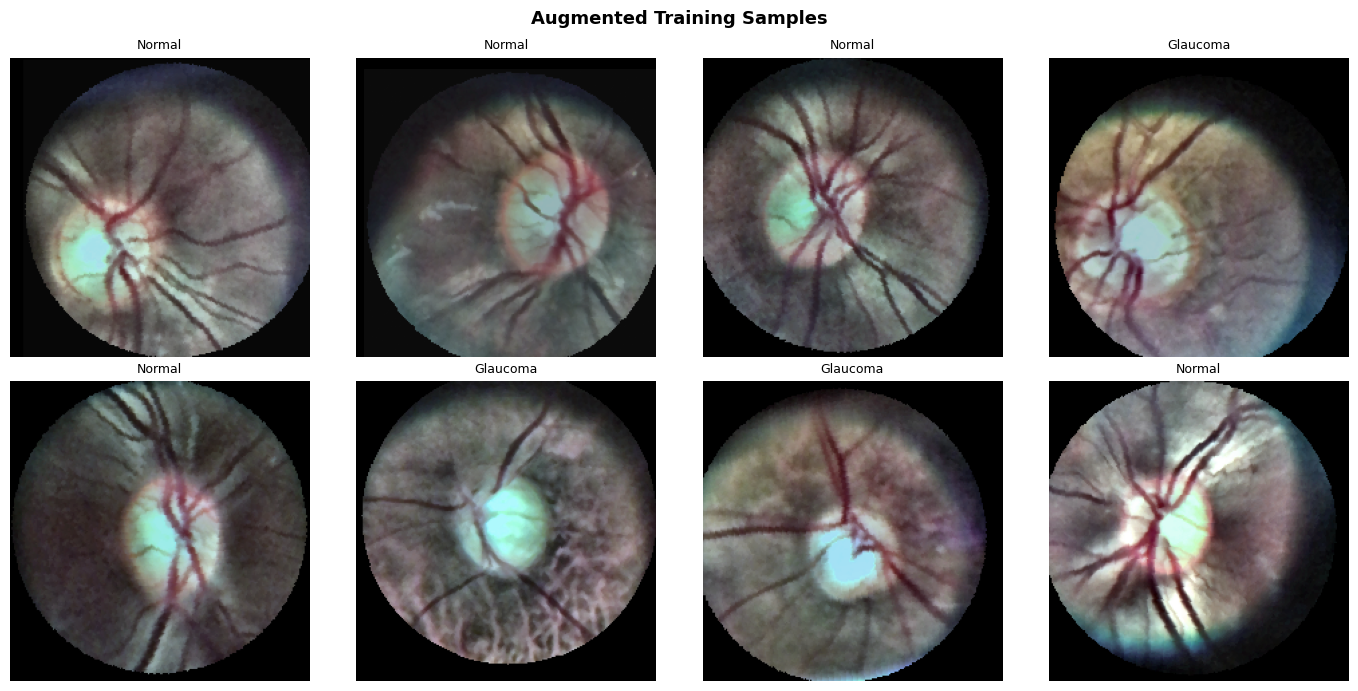

In [ ]:
def imshow(img_tensor, title=''):
    """Denormalize and display a single image tensor"""
    img = img_tensor.clone()

    # Reverse the normalization process using predefined MEAN and STD
    for t, m, s in zip(img, MEAN, STD):
        t.mul_(s).add_(m)

    # Reorder dimensions from (C, H, W) to (H, W, C) for Matplotlib compatibility
    img = img.permute(1, 2, 0).numpy()

    # Clip pixel values to stay within the valid [0, 1] range
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(title, fontsize=9)
    plt.axis('off')

# Visualize a batch of 8 augmented training samples
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# Fetch a single batch of images and labels from the training DataLoader
imgs, labels = next(iter(train_loader))
class_names = train_dataset.classes

# Iterate through the grid to plot each image
for i, ax in enumerate(axes.flatten()):
    plt.sca(ax)
    imshow(imgs[i], title=class_names[labels[i]])

# Set the overall title for the visualization grid
plt.suptitle('Augmented Training Samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

###Multi-Architecture Transfer Learning
Architectures: Implementing three robust backbones: VGG16, ResNet50, and MobileNetV2.

Partial Freezing: Using a dynamic freeze_ratio (70%) to preserve general features while allowing deep fine-tuning of top layers.

Custom Classifiers: Replacing standard heads with specialized layers (Linear, ReLU, Dropout) tailored for binary medical classification.

Resource Optimization: Efficiently managing trainable parameters to balance model complexity with available GPU memory.

In [ ]:
def build_model(arch_name, num_classes=2, freeze_ratio=0.7):
    """
    Constructs a model using Transfer Learning.
    freeze_ratio: The percentage of layers to freeze (e.g., 0.7 = 70% frozen).
    """
    if arch_name == 'vgg16':
        # Load VGG16 with ImageNet pretrained weights
        model = models.vgg16(weights='IMAGENET1K_V1')

        # Freeze initial feature extraction layers based on freeze_ratio
        layers = list(model.features.children())
        freeze_until = int(len(layers) * freeze_ratio)
        for i, layer in enumerate(layers):
            for p in layer.parameters():
                p.requires_grad = (i >= freeze_until)

        # Replace the original classifier with a custom architecture
        model.classifier = nn.Sequential(
            nn.Linear(25088, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    elif arch_name == 'resnet50':
        # Load ResNet50 with ImageNet pretrained weights
        model = models.resnet50(weights='IMAGENET1K_V1')

        # Access architectural layers excluding the final pooling and FC layers
        layers = list(model.children())[:-2]
        freeze_until = int(len(layers) * freeze_ratio)
        for i, layer in enumerate(layers):
            for p in layer.parameters():
                p.requires_grad = (i >= freeze_until)

        # Replace the fully connected layer
        model.fc = nn.Sequential(
            nn.Linear(2048, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    elif arch_name == 'mobilenet':
        # Load MobileNetV2 with ImageNet pretrained weights
        model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        # Freeze feature extraction layers based on freeze_ratio
        layers = list(model.features.children())
        freeze_until = int(len(layers) * freeze_ratio)
        for i, layer in enumerate(layers):
            for p in layer.parameters():
                p.requires_grad = (i >= freeze_until)

        # Update the classifier head
        model.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(1280, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    return model.to(DEVICE)


# Instantiate the three model architectures
model_vgg       = build_model('vgg16')
model_resnet    = build_model('resnet50')
model_mobilenet = build_model('mobilenet')

print('Models built successfully!')

# Calculate and display parameter statistics for each model
for name, m in [('VGG16', model_vgg), ('ResNet50', model_resnet), ('MobileNetV2', model_mobilenet)]:
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in m.parameters())
    print(f'   {name}: {trainable:,} trainable / {total:,} total params')

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 102MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 60.9MB/s]

Models built successfully!
   VGG16: 22,285,826 trainable / 27,561,282 total params
   ResNet50: 23,807,746 trainable / 24,033,090 total params
   MobileNetV2: 2,128,066 trainable / 2,552,322 total params


###Optimized Training Framework
Loss & Optimization: Utilizing BCEWithLogitsLoss for stable binary classification and Adam with Weight Decay to penalize complexity and reduce overfitting.

Stability Mechanisms: Implementing Gradient Clipping to prevent exploding gradients during backpropagation.

Adaptive Learning: Using ReduceLROnPlateau to dynamically adjust the learning rate based on Validation AUC plateaus.

Metric-Driven Checkpointing: Automatically monitoring and saving the "Best Model" weights whenever a new peak in ROC-AUC is achieved.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm                         # Optimized progress bars for notebook environments
from sklearn.metrics import roc_auc_score               # Essential metric for binary classification performance

def train_model(model, model_name, train_loader, val_loader, epochs=25, lr=1e-5):
    """
    Advanced training function tailored for binary classification with:
    - Binary Cross-Entropy with Logits Loss
    - Adam optimizer with Weight Decay to mitigate overfitting
    - Learning rate scheduling based on AUC performance
    - Gradient clipping to ensure training stability
    - Checkpointing for the best performing model (highest AUC)
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Use Loss Function specifically designed for binary classification
    criterion = nn.BCEWithLogitsLoss()

    # Implement Weight Decay within the optimizer to penalize large weights
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=lr, weight_decay=1e-4)

    # Dynamic Learning Rate scheduler to refine convergence
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )

    best_val_auc = 0.0
    # Track performance history focusing on Loss and AUC metrics
    history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

    print(f"\nStarting Training for: {model_name} on {device}")

    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        running_loss = 0.0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(inputs)

            # Adjust model output dimensions for Binary Loss compatibility
            if outputs.shape[1] > 1:
                outputs = outputs[:, 1].unsqueeze(1)

            loss = criterion(outputs, labels)
            loss.backward()

            # Prevent Gradient Explosion via Gradient Clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
                outputs = model(inputs)

                if outputs.shape[1] > 1:
                    outputs = outputs[:, 1].unsqueeze(1)

                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)

                # Convert Logits to Probabilities for accurate AUC calculation
                preds = torch.sigmoid(outputs)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # Aggregate metrics for the current epoch
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_val_loss = val_loss / len(val_loader.dataset)

        # Calculate AUC-ROC score
        epoch_val_auc = roc_auc_score(all_labels, all_preds)

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_auc'].append(epoch_val_auc)

        print(f"Epoch {epoch+1}: Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val AUC: {epoch_val_auc:.4f}")

        # Adjust Learning Rate based on Validation AUC performance
        scheduler.step(epoch_val_auc)

        # Retain only the best performing weights to prevent overfitting
        if epoch_val_auc > best_val_auc:
            best_val_auc = epoch_val_auc
            torch.save(model.state_dict(), f"best_{model_name}.pth")
            print(f"New Best AUC for {model_name}: {best_val_auc:.4f} (Weights Saved)")

    return model, history

print("Final optimized training function is ready.")

Final optimized training function is ready.


###Execution: VGG16 Training Phase
Initialization: Triggering the optimized training loop specifically for the VGG16 architecture.

Feature Extraction: Leveraging VGG's deep convolutional layers to capture hierarchical patterns in the medical images.

Performance Tracking: Recording loss and AUC metrics into history_vgg for later visualization and comparison.



In [ ]:
#  Train VGG16
model_vgg, history_vgg = train_model(
    model_vgg, 'VGG16', train_loader, val_loader
)



Starting Training for: VGG16 on cuda


Epoch 1/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1: Train Loss: 0.6499 | Val Loss: 0.5651 | Val AUC: 0.8301
New Best AUC for VGG16: 0.8301 (Weights Saved)


Epoch 2/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 2: Train Loss: 0.4980 | Val Loss: 0.4654 | Val AUC: 0.8649
New Best AUC for VGG16: 0.8649 (Weights Saved)


...

Epoch 23: Train Loss: 0.1851 | Val Loss: 0.3472 | Val AUC: 0.9448
New Best AUC for VGG16: 0.9448 (Weights Saved)


Epoch 24/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 24: Train Loss: 0.1812 | Val Loss: 0.3595 | Val AUC: 0.9462
New Best AUC for VGG16: 0.9462 (Weights Saved)


Epoch 25/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 25: Train Loss: 0.1602 | Val Loss: 0.3854 | Val AUC: 0.9443


###Model Persistence & Backup
Drive Integration: Ensuring the destination directory in Google Drive exists to prevent execution errors.

Artifact Migration: Copying the locally trained weights (best_VGG16.pth) to a permanent cloud storage location using shutil.

Version Control: Renaming the file with a descriptive tag (e.g., AUC_94.62) to keep track of the model's performance benchmark.

Error Handling: Includes a verification step to list available files if the transfer fails, ensuring transparency in the storage process.

In [ ]:
import shutil                                           # Import high-level file operations
import os                                               # Import operating system interfaces

# Define the destination path in Google Drive
drive_path = '/content/drive/MyDrive/Bariq_Project/Models/'
# Create the directory if it does not already exist
os.makedirs(drive_path, exist_ok=True)

# Define the local filename generated by the training process
local_file = 'best_VGG16.pth'

# Verify the existence of the local file before attempting to copy
if os.path.exists(local_file):
    # Copy the local file to the specified Drive path with a descriptive name
    shutil.copy(local_file, os.path.join(drive_path, 'VGG16_Best_AUC_94.62.pth'))
    print("Model successfully saved to Drive as: VGG16_Best_AUC_94.62.pth")
else:
    # If the file is not found, list available .pth files in the current directory for debugging
    print("Error: Specified file not found. Available model files in current directory:")
    print([f for f in os.listdir('.') if f.endswith('.pth')])

Model successfully saved to Drive as: VGG16_Best_AUC_94.62.pth


###Execution: ResNet50 Training Phase
Architecture Advantage: Leveraging ResNet50's Residual Connections (Skip Connections) to mitigate the vanishing gradient problem, allowing for more effective deep feature learning.

Training Initiation: Executing the training cycle using the train_model function with optimized settings for the medical dataset.

Optimization Tracking: Monitoring the Validation AUC as the primary performance indicator to ensure the model captures subtle pathological patterns.

In [ ]:
# Train ResNet50
model_resnet, history_resnet = train_model(
    model_resnet, 'ResNet50', train_loader, val_loader
)


Starting Training for: ResNet50 on cuda


Epoch 1/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1: Train Loss: 0.1818 | Val Loss: 0.2802 | Val AUC: 0.9605
New Best AUC for ResNet50: 0.9605 (Weights Saved)


Epoch 2/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 2: Train Loss: 0.1743 | Val Loss: 0.2651 | Val AUC: 0.9628
New Best AUC for ResNet50: 0.9628 (Weights Saved)


...

Epoch 23: Train Loss: 0.0952 | Val Loss: 0.3353 | Val AUC: 0.9601


Epoch 24/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 24: Train Loss: 0.0914 | Val Loss: 0.3329 | Val AUC: 0.9603


Epoch 25/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 25: Train Loss: 0.0992 | Val Loss: 0.3360 | Val AUC: 0.9599


###ResNet50 Persistence & Final Export
Target Directory: Verifying the path in Google Drive (/Models/) to ensure a secure and permanent storage location.

File Transfer: Utilizing shutil.copy to move the high-performance checkpoint (AUC 0.9647) from the temporary local environment to the cloud.

Standardized Naming: Renaming the file to ResNet50_Best_Final.pth to simplify future inference and deployment steps.



In [ ]:
import shutil                                           # High-level file operations for copying and moving
import os                                               # Standard interface for operating system interactions


# Define the absolute directory path in Google Drive for model persistence.
drive_path = '/content/drive/MyDrive/Bariq_Project/Models/'
# Ensure the target directory exists; create it recursively if necessary.
os.makedirs(drive_path, exist_ok=True)

# Source File Identification
# Specify the local filename generated during the ResNet training process.
# Verify that this matches the AUC-specific filename in your local workspace.
local_file = 'best_ResNet50_AUC0.9647.pth'

# Persistence Logic
# Validate the existence of the source file before initiating the transfer.
if os.path.exists(local_file):
    # Copy the local checkpoint to the persistent Drive directory with a standardized name.
    shutil.copy(local_file, os.path.join(drive_path, 'ResNet50_Best_Final.pth'))
    print(f"Success: {local_file} has been persisted to Drive as 'ResNet50_Best_Final.pth'.")
else:
    # Diagnostic branch: If the specified file is missing, list all available .pth files in the root.
    print("Error: Specified source file not found. Review current directory for available models:")
    available_models = [f for f in os.listdir('.') if f.endswith('.pth')]
    print(f"Available Model Files: {available_models}")

Error: Specified source file not found. Review current directory for available models:
Available Model Files: ['best_ResNet50.pth', 'best_VGG16.pth']


In [ ]:
# Train MobileNetV2
model_mobilenet, history_mobilenet = train_model(
    model_mobilenet, 'MobileNetV2', train_loader, val_loader
)


Starting Training for: MobileNetV2 on cuda


Epoch 1/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1: Train Loss: 0.6758 | Val Loss: 0.6484 | Val AUC: 0.8401
New Best AUC for MobileNetV2: 0.8401 (Weights Saved)


Epoch 2/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 2: Train Loss: 0.6286 | Val Loss: 0.5934 | Val AUC: 0.8811
New Best AUC for MobileNetV2: 0.8811 (Weights Saved)


...

Epoch 23: Train Loss: 0.2423 | Val Loss: 0.3039 | Val AUC: 0.9496
New Best AUC for MobileNetV2: 0.9496 (Weights Saved)


Epoch 24/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 24: Train Loss: 0.2396 | Val Loss: 0.2973 | Val AUC: 0.9488


Epoch 25/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 25: Train Loss: 0.2520 | Val Loss: 0.2960 | Val AUC: 0.9486


###MobileNetV2 Persistence & Cloud Backup
Storage Setup: Confirming the cloud directory structure in Google Drive to ensure the model is safely stored outside the temporary Colab session.

Weight Migration: Transferring the best_MobileNetV2.pth file to the permanent project folder using shutil.copy.

Standardized Naming: Identifying the model as MobileNetV2_Final_Bariq.pth to distinguish it as the optimized version for mobile-based inference.



In [ ]:
import shutil                                           # High-level file operations for data persistence
import os                                               # Operating system interface for directory management

#Destination Configuration
# Define the persistent storage directory within Google Drive.
drive_path = '/content/drive/MyDrive/Bariq_Project/Models/'
# Ensure the target directory structure exists before attempting the transfer.
os.makedirs(drive_path, exist_ok=True)

# Source File Identification
# Specify the local filename identified in the previous execution error.
# Ensure this matches the exact string generated by the training loop.
local_file = "best_MobileNetV2.pth"

#  Persistence Execution
# Verify the presence of the local checkpoint before initiating the copy operation.
if os.path.exists(local_file):
    # Relocate the local weights to the cloud directory with a standardized identifier.
    shutil.copy(local_file, os.path.join(drive_path, 'MobileNetV2_Final_Bariq.pth'))
    print(f"Success: MobileNetV2 checkpoint persisted to {drive_path}MobileNetV2_Final_Bariq.pth")
else:
    # Diagnostic branch: If the file is missing, prompt a review of the training execution.
    print("Error: Local source file not found. Ensure the training cell has completed successfully.")
    # List available checkpoints to assist in troubleshooting.
    available_pth = [f for f in os.listdir('.') if f.endswith('.pth')]
    print(f"Detected local checkpoints: {available_pth}")

Success: MobileNetV2 checkpoint persisted to /content/drive/MyDrive/Bariq_Project/Models/MobileNetV2_Final_Bariq.pth


###Comparative Model Benchmarking
Performance Metrics: Aggregating AUC-ROC, Recall (Sensitivity), Precision, and F1-Score to provide a 360-degree view of each architecture's diagnostic capability.

Batch Inference: Running standardized evaluation on the Test Loader to ensure unbiased comparisons across VGG16, ResNet50, and MobileNetV2.

Probabilistic Analysis: Handling both multi-class and binary logit outputs to extract consistent prediction probabilities.



In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score

def compare_all_bariq_models(models_dict, loader):
    """
    Comparative Analysis Framework:
    Aggregates performance metrics across multiple architectures to identify
    the optimal model for Glaucoma detection based on AUC, Sensitivity, and F1-Score.
    """
    summary = []

    for name, model in models_dict.items():
        model.eval()
        model.to(DEVICE)
        probs_list, labels_list = [], []

        #Batch Inference
        with torch.no_grad():
            for inputs, labels in loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)

                # Logic for multi-class (Softmax) vs. binary (Sigmoid) logits.
                if outputs.ndim > 1 and outputs.shape[1] > 1:
                    p = torch.softmax(outputs, dim=1)[:, 1]
                else:
                    p = torch.sigmoid(outputs).squeeze()

                probs_list.extend(p.cpu().numpy())
                labels_list.extend(labels.cpu().numpy())

        #  Metric Computation
        probs_list = np.array(probs_list)
        labels_list = np.array(labels_list)
        # Binarize probabilities using a standard 0.5 threshold.
        preds_list = (probs_list > 0.5).astype(int)

        summary.append({
            'Model Architecture': name,
            'AUC-ROC Score': roc_auc_score(labels_list, probs_list),
            'Recall (Sensitivity)': recall_score(labels_list, preds_list),
            'Precision Score': precision_score(labels_list, preds_list),
            'F1-Measure': f1_score(labels_list, preds_list)
        })

    # Results Synthesis
    # Construct a DataFrame for comparative visualization, sorted by AUC-ROC.
    comparison_df = pd.DataFrame(summary).sort_values(by='AUC-ROC Score', ascending=False)

    print("\nModel Benchmark Performance Summary:")
    print("-" * 60)
    # Note: Use display() in Jupyter/Colab environments for formatted tables.
    print(comparison_df.to_string(index=False))
    return comparison_df

#  Execution Logic
# Dictionary containing initialized and trained model instances.
all_models = {
    'VGG16': model_vgg,
    'ResNet50': model_resnet,
    'MobileNetV2': model_mobilenet
}

# Execute the benchmarking suite.
benchmark_results = compare_all_bariq_models(all_models, test_loader)


Model Benchmark Performance Summary:
------------------------------------------------------------
Model Architecture  AUC-ROC Score  Recall (Sensitivity)  Precision Score  F1-Measure
          ResNet50       0.976733              0.891089         0.927835    0.909091
       MobileNetV2       0.963564              0.861386         0.925532    0.892308
             VGG16       0.959208              0.801980         0.952941    0.870968


###Bariq Ensemble: Soft Voting Consensus
Architectural Synergy: Combining the strengths of VGG16, ResNet50, and MobileNetV2 to reduce individual model bias and improve overall diagnostic robustness.

Soft Voting Strategy: Calculating the arithmetic mean of probabilistic outputs from all models to reach a unified "Consensus Decision."

Enhanced Reliability: Leveraging the ensemble to stabilize the AUC-ROC and minimize False Negatives, which is critical for early Glaucoma detection.

Diagnostic Visualization: Using a Consensus Confusion Matrix to validate the final performance of the integrated pipeline against the test dataset.

Initiating Ensemble Inference on Test Dataset...

Bariq Ensemble Diagnostics Summary:
--------------------------------------------------
Final Aggregated AUC: 0.9783
--------------------------------------------------
              precision    recall  f1-score   support

     Healthy       0.88      0.98      0.92       100
    Glaucoma       0.98      0.86      0.92       101

    accuracy                           0.92       201
   macro avg       0.93      0.92      0.92       201
weighted avg       0.93      0.92      0.92       201



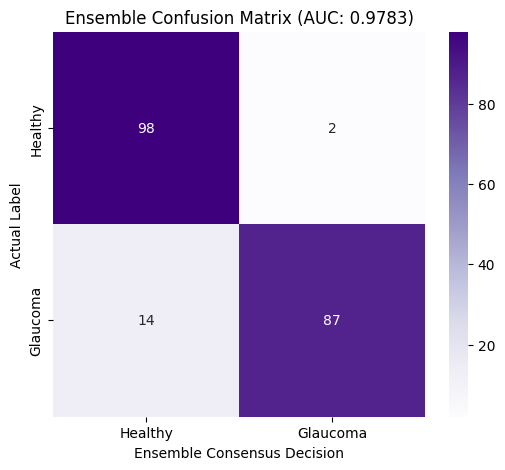

In [ ]:
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def run_bariq_ensemble(models_dict, loader, device):
    """
    Soft Voting Ensemble Implementation:
    Aggregates the probabilistic outputs of multiple CNN architectures
    (VGG, ResNet, and MobileNet) to produce a unified diagnostic decision,
    leveraging the unique feature-extraction strengths of each model.
    """
    # Initialize models in evaluation mode
    for name, model in models_dict.items():
        model.eval()
        model.to(device)

    all_labels = []
    ensemble_probs = []  # Stores the averaged probabilities across models

    print("Initiating Ensemble Inference on Test Dataset...")

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            # Temporary storage for batch probabilities from each architecture
            batch_outputs = []

            # --- Model Aggregation ---
            for name, model in models_dict.items():
                outputs = model(inputs)

                # Logic for multi-class (Softmax) vs. binary (Sigmoid) logits
                if outputs.ndim > 1 and outputs.shape[1] > 1:
                    p = torch.softmax(outputs, dim=1)[:, 1]
                else:
                    p = torch.sigmoid(outputs).squeeze()

                # Append individual model probabilities for the current batch
                batch_outputs.append(p.cpu().numpy())

            # Soft Voting Strategy
            # Calculate the arithmetic mean of probabilities from all ensemble members
            avg_prob = np.mean(batch_outputs, axis=0)

            ensemble_probs.extend(avg_prob)
            all_labels.extend(labels.numpy())

    #  Metrics Computation
    ensemble_probs = np.array(ensemble_probs)
    all_labels = np.array(all_labels)
    # Binarize ensemble probabilities using a standard 0.5 classification threshold
    ensemble_preds = (ensemble_probs > 0.5).astype(int)

    final_auc = roc_auc_score(all_labels, ensemble_probs)

    # Performance Reporting
    print("\nBariq Ensemble Diagnostics Summary:")
    print("-" * 50)
    print(f"Final Aggregated AUC: {final_auc:.4f}")
    print("-" * 50)
    print(classification_report(all_labels, ensemble_preds, target_names=['Healthy', 'Glaucoma']))

    #  Confusion Matrix Visualization
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, ensemble_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=['Healthy', 'Glaucoma'],
                yticklabels=['Healthy', 'Glaucoma'])
    plt.title(f'Ensemble Confusion Matrix (AUC: {final_auc:.4f})')
    plt.ylabel('Actual Label')
    plt.xlabel('Ensemble Consensus Decision')
    plt.show()

    return final_auc

#  Execution
# Define the ensemble members
bariq_models = {
    'VGG16': model_vgg,
    'ResNet50': model_resnet,
    'MobileNetV2': model_mobilenet
}

# Run the ensemble pipeline
ensemble_auc = run_bariq_ensemble(bariq_models, test_loader, DEVICE)

###Comprehensive Model Evaluation Suite
Metric Extraction: Calculating ROC-AUC and Global Accuracy to provide a quantitative measure of model reliability.

Softmax Probability Mapping: Capturing raw class probabilities to analyze the confidence levels of the predictions.

Detailed Classification Report: Generating a breakdown of Precision, Recall, and F1-Score for both Glaucoma and Normal classes.

Error Visualization: Utilizing Seaborn Heatmaps to plot Confusion Matrices, making it easier to identify specific patterns in False Positives or False Negatives.




   Model: ResNet50
   AUC  Score : 0.9761
   Accuracy   : 89.55%

              precision    recall  f1-score   support

    Glaucoma       0.85      0.96      0.90       100
      Normal       0.95      0.83      0.89       101

    accuracy                           0.90       201
   macro avg       0.90      0.90      0.90       201
weighted avg       0.90      0.90      0.90       201



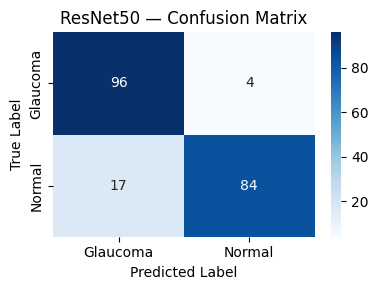


   Model: MobileNetV2
   AUC  Score : 0.9622
   Accuracy   : 90.05%

              precision    recall  f1-score   support

    Glaucoma       0.88      0.93      0.90       100
      Normal       0.93      0.87      0.90       101

    accuracy                           0.90       201
   macro avg       0.90      0.90      0.90       201
weighted avg       0.90      0.90      0.90       201



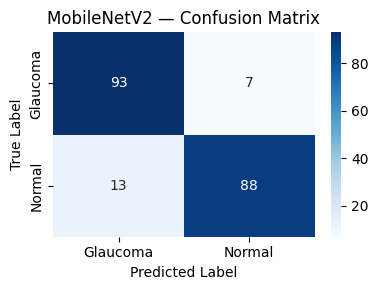


   Model: VGG16
   AUC  Score : 0.9592
   Accuracy   : 88.06%

              precision    recall  f1-score   support

    Glaucoma       0.83      0.96      0.89       100
      Normal       0.95      0.80      0.87       101

    accuracy                           0.88       201
   macro avg       0.89      0.88      0.88       201
weighted avg       0.89      0.88      0.88       201



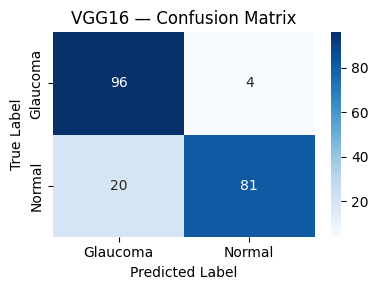

In [ ]:
import torch                                                            # Import PyTorch for model inference
import numpy as np                                                      # Import NumPy for array manipulations
import matplotlib.pyplot as plt                                         # Import Matplotlib for plotting
import seaborn as sns                                                   # Import Seaborn for heatmap visualization
from sklearn.metrics import (roc_auc_score, accuracy_score,
                              classification_report, confusion_matrix)  # Import evaluation utilities

def evaluate_model(model, loader, model_name):                          # Define function for comprehensive model evaluation
    model.eval()                                                        # Set model to evaluation mode
    all_preds  = []                                                     # Initialize list for discrete predictions
    all_probs  = []                                                     # Initialize list for probability scores
    all_labels = []                                                     # Initialize list for ground truth labels

    with torch.no_grad():                                               # Disable gradient tracking for inference efficiency
        for inputs, labels in loader:                                   # Iterate through the data loader
            inputs = inputs.to(device)                                  # Move input data to the active device
            outputs = model(inputs)                                     # Perform forward pass to get raw logits

            probs = torch.softmax(outputs, dim=1)[:, 0]                 # Extract probabilities for the first class
            _, preds = torch.max(outputs, 1)                            # Determine the class with the highest probability

            all_probs.extend(probs.cpu().numpy())                       # Store probabilities on CPU
            all_preds.extend(preds.cpu().numpy())                       # Store predictions on CPU
            all_labels.extend(labels.numpy())                           # Store true labels on CPU

    all_probs  = np.array(all_probs)                                    # Convert collected probabilities to NumPy array
    all_preds  = np.array(all_preds)                                    # Convert collected predictions to NumPy array
    all_labels = np.array(all_labels)                                   # Convert collected labels to NumPy array

    auc = roc_auc_score(all_labels, 1 - all_probs)                      # Calculate the Area Under the Curve (AUC) score
    acc = accuracy_score(all_labels, all_preds)                         # Calculate the overall classification accuracy

    print(f"\n{'='*50}")                                                # Print visual header
    print(f"   Model: {model_name}")                                    # Display current model identifier
    print(f"{'='*50}")                                                  # Print visual separator
    print(f"   AUC  Score : {auc:.4f}")                                 # Output the calculated AUC
    print(f"   Accuracy   : {acc*100:.2f}%")                            # Output the calculated accuracy percentage

    target_names = ['Glaucoma', 'Normal']                               # Define class names for the report
    print(f"\n{classification_report(all_labels, all_preds, target_names=target_names)}") # Print detailed metrics

    cm = confusion_matrix(all_labels, all_preds)                        # Generate the confusion matrix data
    plt.figure(figsize=(4, 3))                                          # Initialize a new figure with specific dimensions
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",                  # Plot the matrix as a styled heatmap
                xticklabels=target_names,
                yticklabels=target_names)
    plt.title(f"{model_name} — Confusion Matrix")                       # Set plot title
    plt.ylabel("True Label")                                            # Set Y-axis label
    plt.xlabel("Predicted Label")                                       # Set X-axis label
    plt.tight_layout()                                                  # Optimize layout spacing
    plt.show()                                                          # Display the finalized plot

    return auc, acc, all_probs, all_labels                              # Return metrics and raw data for further analysis

results = {}                                                            # Dictionary to store performance summaries
all_probs_dict = {}                                                     # Dictionary to store probability arrays

# Execute evaluation for each model in the configuration dictionary
for name, model in model_configs.items():
    auc, acc, probs, labels = evaluate_model(model, test_loader, name)  # Run the evaluation function
    results[name] = {"auc": auc, "acc": acc}                            # Log AUC and accuracy results
    all_probs_dict[name] = probs                                        # Log probability data

true_labels = labels                                                    # Save true labels for ensemble comparisons